In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv(r'..\data\consolidated_weather_pathdelay.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209693 entries, 0 to 209692
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                209693 non-null  int64  
 1   t_sec                     209693 non-null  int64  
 2   cloud-cover_x             209693 non-null  float64
 3   humidity_x                209693 non-null  float64
 4   pressure-surface-level_x  209693 non-null  float64
 5   temperature_x             209693 non-null  float64
 6   visibility_x              209693 non-null  float64
 7   wind-gust_x               209693 non-null  float64
 8   wind-speed_x              209693 non-null  float64
 9   wind_dir_sin_x            209693 non-null  float64
 10  wind_dir_cos_x            209693 non-null  float64
 11  wind_u_x                  209693 non-null  float64
 12  wind_v_x                  209693 non-null  float64
 13  cloud-cover_y             209693 non-null  f

In [17]:
df["temperature"] = (df["temperature_x"] + df["temperature_y"]) / 2
df = df[["temperature", "t_sec", "path_delay", "clock_error"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209693 entries, 0 to 209692
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   temperature  209693 non-null  float64
 1   t_sec        209693 non-null  int64  
 2   path_delay   209693 non-null  float64
 3   clock_error  209693 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 6.4 MB


In [18]:
print(df.head())

   temperature       t_sec     path_delay  clock_error
0       19.995  1696017907  640602.630000     0.000000
1       19.995  1696017908  640602.622333     2.138276
2       19.995  1696017909  640602.609000     1.978468
3       19.995  1696017910  640602.608000     0.700260
4       19.995  1696017911  640602.601000    -1.851184


In [19]:
df.describe()

,temperature,t_sec,path_delay,clock_error
count,209693.000000,2.096930e+05,209693.000000,209693.000000
mean,19.138299,1.696141e+09,640593.509670,30.578311
std,3.306002,7.088140e+04,22.767584,17.660571
min,14.595000,1.696018e+09,640568.100000,-23.344499
25%,16.468158,1.696080e+09,640574.470000,16.065980
50%,18.190000,1.696141e+09,640583.733500,30.511300
75%,21.620000,1.696202e+09,640611.136000,42.951760
max,26.380000,1.696263e+09,640642.659000,103.188933


In [20]:
df.to_csv(r'..\data\time_of_flight.csv')

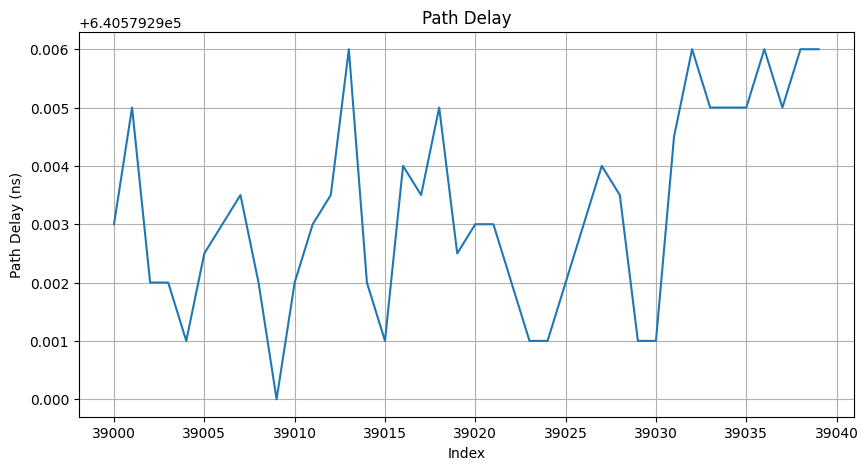

In [26]:
df_plot = df.iloc[39000:39040]
df_plot["path_delay"].plot(figsize=(10, 5), title="Path Delay")
plt.xlabel("Index")
plt.ylabel("Path Delay (ns)")
plt.grid(True)
plt.show()

In [27]:
std_val = df.iloc[39000:39040]["path_delay"].std()
print(f"Standard deviation: {std_val:.3f}")

Standard deviation: 0.002


In [34]:
df_res = pd.read_csv(r'..\examples\time_of_flight_output.csv')
df_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209693 entries, 0 to 209692
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   epoch                     209693 non-null  int64  
 1   photon_name               209693 non-null  object 
 2   input_t_sec               209693 non-null  float64
 3   input_path_delay_ns       209693 non-null  float64
 4   input_path_delay_ps       209693 non-null  float64
 5   temperature               209693 non-null  float64
 6   channel_distance_m        209693 non-null  float64
 7   send_time_ps              209693 non-null  int64  
 8   arrival_time_ps_raw       209693 non-null  int64  
 9   arrival_time_ps_reported  209693 non-null  int64  
 10  flight_time_ps_raw        209693 non-null  int64  
 11  flight_time_ps_reported   209693 non-null  int64  
 12  arrival_t_sec_raw         209693 non-null  float64
 13  arrival_t_sec_reported    209693 non-null  f

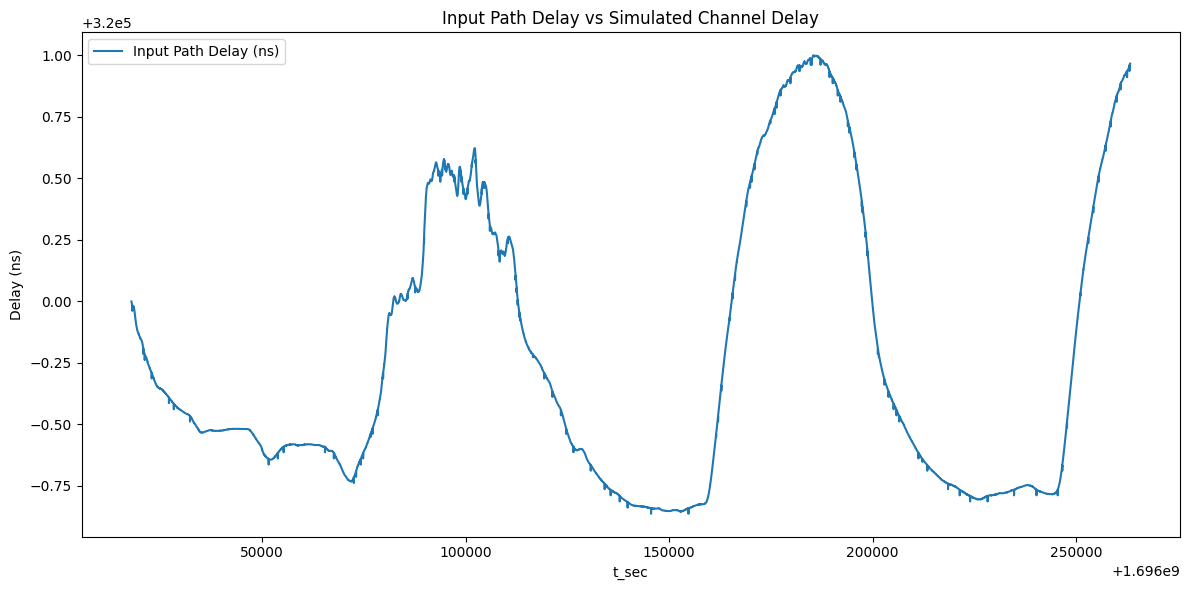

In [44]:
df_res.columns = df_res.columns.str.strip()

# Convert simulated channel delay from ps to ns
df_res["simulated_channel_delay_ns"] = df_res["flight_time_ps_raw"] / 1000.0

# Estimated vars based on simulated res
df_res["input_path_delay_ns_offset"] = 320_000 + (df_res["input_path_delay_ns"] - df_res["input_path_delay_ns"][0]) / 40.0

plt.figure(figsize=(12, 6))
plt.plot(df_res["input_t_sec"], df_res["input_path_delay_ns_offset"], label="Input Path Delay (ns)")
#plt.plot(df_res["input_t_sec"], df_res["simulated_channel_delay_ns"], label="Simulated Channel Delay (ns)")

plt.xlabel("t_sec")
plt.ylabel("Delay (ns)")
plt.title("Input Path Delay vs Simulated Channel Delay")
plt.legend()
plt.tight_layout()
plt.show()

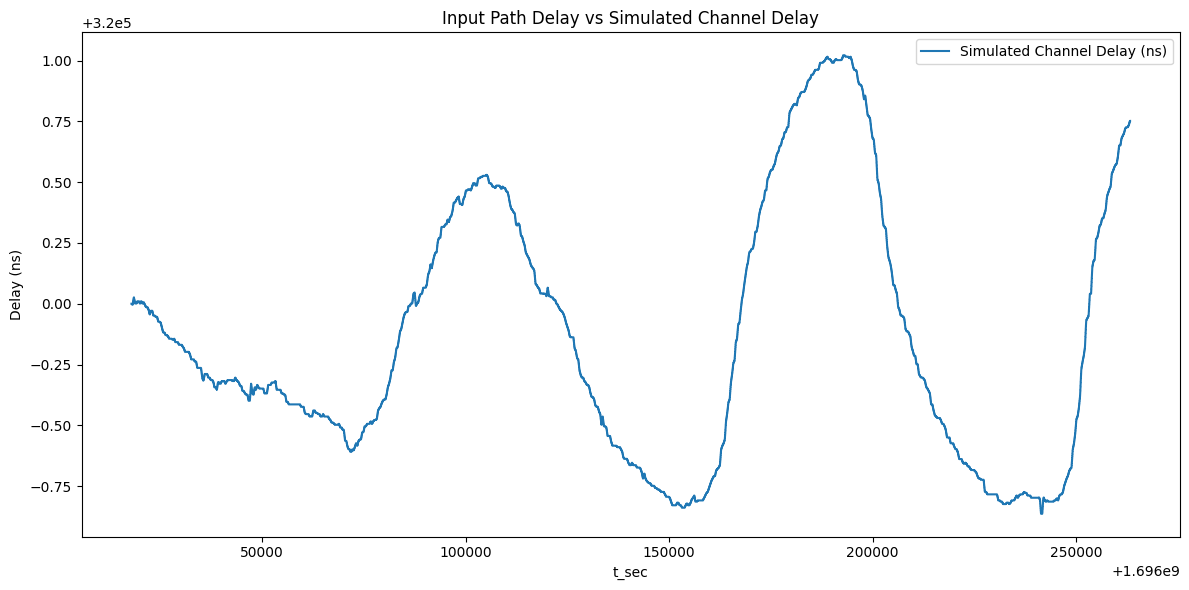

In [45]:
plt.figure(figsize=(12, 6))
#plt.plot(df_res["input_t_sec"], df_res["input_path_delay_ns"], label="Input Path Delay (ns)")
plt.plot(df_res["input_t_sec"], df_res["simulated_channel_delay_ns"], label="Simulated Channel Delay (ns)")

plt.xlabel("t_sec")
plt.ylabel("Delay (ns)")
plt.title("Input Path Delay vs Simulated Channel Delay")
plt.legend()
plt.tight_layout()
plt.show()

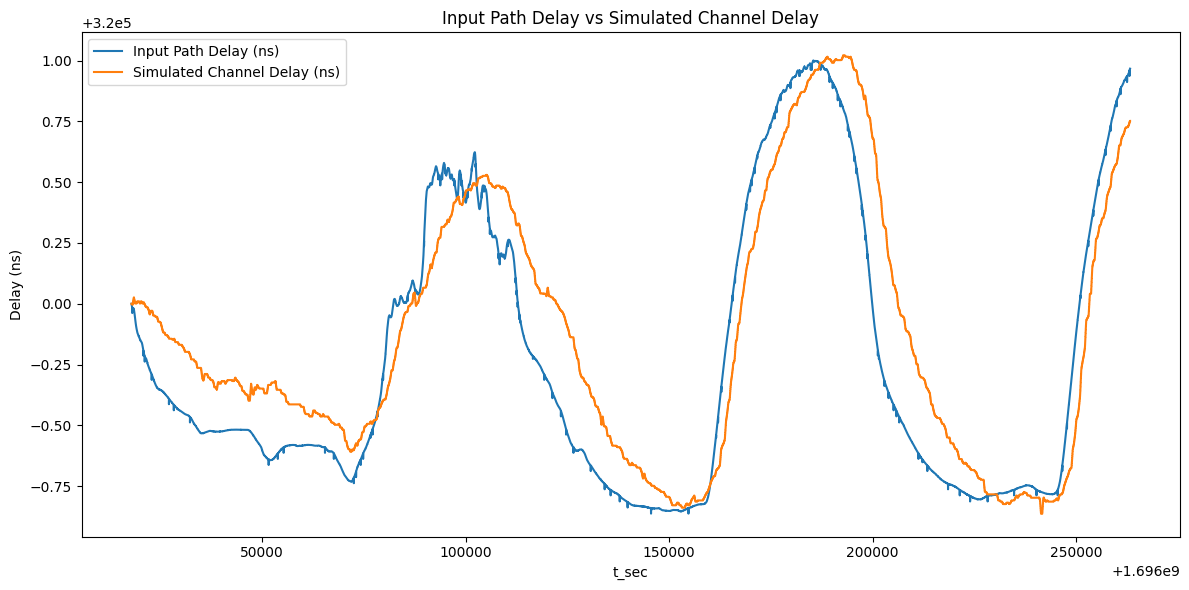

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(df_res["input_t_sec"], df_res["input_path_delay_ns_offset"], label="Input Path Delay (ns)")
plt.plot(df_res["input_t_sec"], df_res["simulated_channel_delay_ns"], label="Simulated Channel Delay (ns)")

plt.xlabel("t_sec")
plt.ylabel("Delay (ns)")
plt.title("Input Path Delay vs Simulated Channel Delay")
plt.legend()
plt.tight_layout()
plt.show()